# NaV1.5 Figure 5: IFM constraint and pore-state exploration

This notebook assembles the focused main-text comparisons for the NaV1.5 figure. The intact MSA is retained as the native-state benchmark, whereas the selected original QQQ mask is evaluated as an exploratory mutant protocol. Alternative masks remain important controls but are intentionally excluded from these panels to keep the main comparison readable.

Experimental structures use the same color and marker assignments as the other NaV1.5 distance and RMSD notebooks.

In [1]:
from pathlib import Path
import importlib
import sys
import pandas as pd
import matplotlib.pyplot as plt

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'shared').is_dir())
sys.path.insert(0, str(repo_root)) if str(repo_root) not in sys.path else None

from shared.plotting import apply_kv21_style
from shared.nav15_pore_shape import ensemble_gate_shape, experimental_gate_shape
from shared.nav15_presentation import presentation_table
import shared.nav15_figure5 as nav15_figure5
importlib.reload(nav15_figure5)
from shared.nav15_figure5 import (
    plot_mask_tradeoff,
    plot_focused_pore_shape,
    plot_pore_rmsd_summary,
    plot_figure5_pore_candidates,
)

apply_kv21_style()
data_dir = repo_root / 'nav15' / 'dataDistances'
figure_dir = repo_root.parent / 'vgci_mutants_writing' / 'figures' / 'nav15' / 'figure5'
figure_dir.mkdir(parents=True, exist_ok=True)
figure_dir

PosixPath('/Users/ahernandezgonzalez/Repositories/vgci_mutants_writing/figures/nav15/figure5')

## Final-QC ensembles

All ensemble panels use the final allOK3 distance tables. The WT comparison uses masked v2 because it is the matched WT mask with complete final-QC coverage. The mutant comparison uses the original QQQ mask because it produced the clearest exploratory pore response.

In [2]:
specs = {
    'WT | vanilla': ('26-07-27_Nav15_wt_vanillaAF2_distances_all_ok_rmsd_3A.csv', 'WT'),
    'WT | masked v2': ('26-07-27_Nav15_wt_maskedv2_AF2_distances_all_ok_rmsd_3A.csv', 'WT'),
    'QQQ | vanilla': ('26-07-27_Nav15_qqq_vanilla_AF2_distances_all_ok_rmsd_3A.csv', 'QQQ'),
    'QQQ | masked': ('26-07-27_Nav15_qqq_masked_AF2_distances_all_ok_rmsd_3A.csv', 'QQQ'),
}
datasets = {
    label: (pd.read_csv(data_dir / filename, low_memory=False), condition)
    for label, (filename, condition) in specs.items()
}
summary, model_metrics = presentation_table(datasets)
experimental_shape, experimental_distance_audit = experimental_gate_shape(
    repo_root / 'nav15' / 'experimental'
)
ensemble_shape = pd.concat(
    [
        ensemble_gate_shape(datasets['QQQ | vanilla'][0], 'QQQ | vanilla'),
        ensemble_gate_shape(datasets['QQQ | masked'][0], 'QQQ | masked'),
    ],
    ignore_index=True,
)
display(summary.round(3))
display(
    experimental_shape[
        ['dataset', 'state', 'mean_diagonal_A', 'side_aspect_ratio']
    ].round(3)
)

,Dataset,Condition,n,Pocket-engaged fraction,Pocket mean median (Å),Gate diagonal median (Å),Gate aspect median
0,WT | vanilla,WT,5000,0.559,7.750,15.075,1.232
1,WT | masked v2,WT,4999,0.034,19.667,15.385,1.247
2,QQQ | vanilla,QQQ,5000,0.049,19.333,14.970,1.220
3,QQQ | masked,QQQ,4999,0.001,19.233,16.500,1.180


,dataset,state,mean_diagonal_A,side_aspect_ratio
0,6UZ3,WT inactivated,15.468,1.121
1,7FBS,QQQ engineered open,16.799,1.203
2,8T6L,toxin-bound,15.508,1.091
3,7DTC,E1784K intermediate-inactivated,15.172,1.115
4,8VYJ,"full-length open, Model I",16.543,1.100
5,8VYK,"full-length expanded open, Model II",17.044,1.137


## Native-state cost and mutant pore response

The first panel preserves the central trade-off: masking strongly reduces native IFM-pocket engagement in WT, while the selected QQQ mask shifts the intracellular gate. Experimental markers are collected in a dedicated reference column rather than being placed ambiguously between ensemble violins.

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/nav15_figure5.py:183: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/nav15_figure5.py:183: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


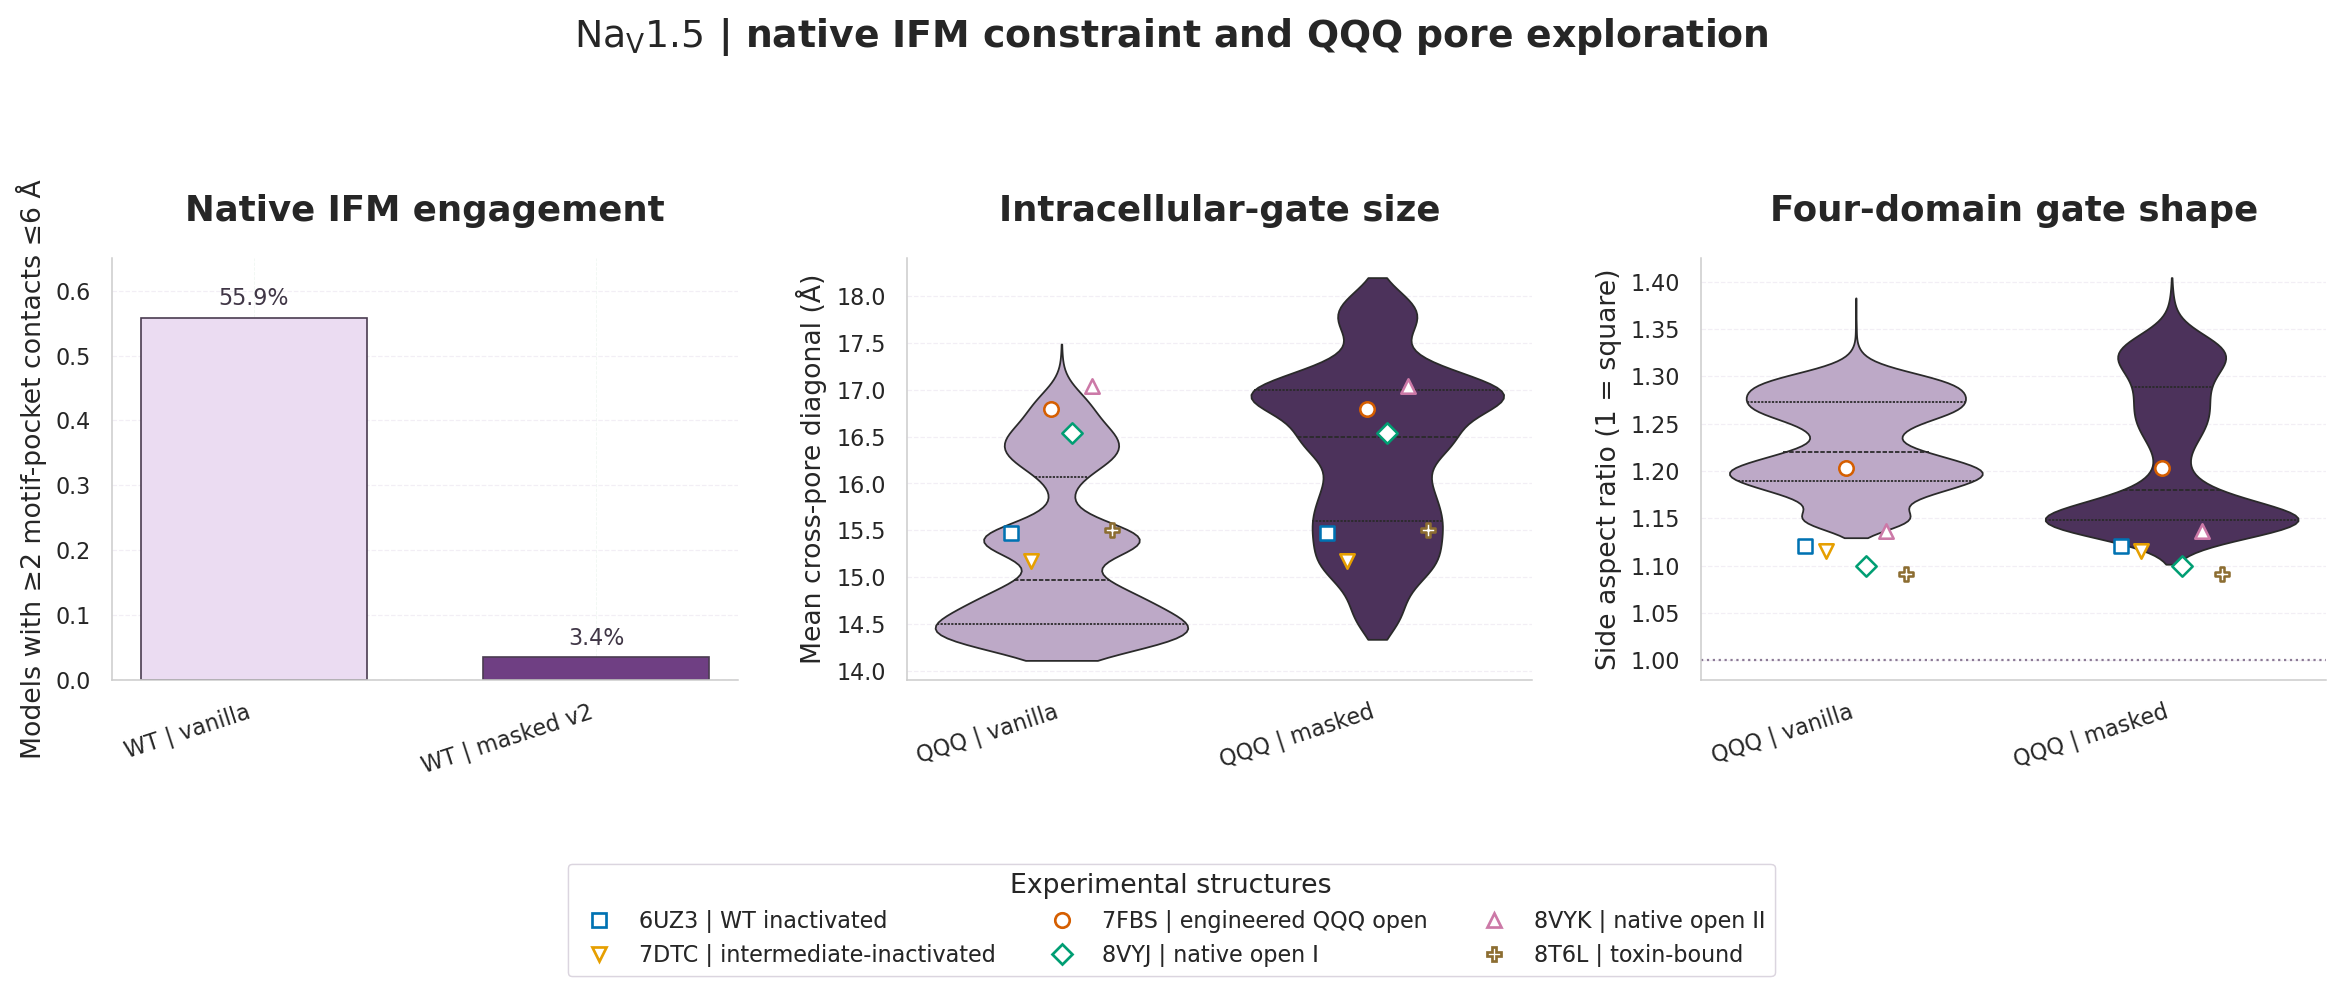

In [3]:
fig = plot_mask_tradeoff(summary, model_metrics, experimental_shape)
fig.savefig(figure_dir / 'Nav15_Figure5_mask_tradeoff.png', dpi=600, bbox_inches='tight')
fig.savefig(figure_dir / 'Nav15_Figure5_mask_tradeoff.pdf', bbox_inches='tight')
plt.show()

## Joint intracellular-gate geometry

The gate is represented as a cyclic four-domain quadrilateral. Its size coordinate is

$$d_{\mathrm{gate}} = \frac{d_{\mathrm{DI-DIII}} + d_{\mathrm{DII-DIV}}}{2},$$

and the shape coordinate is the ratio between the longer and shorter mean opposite-side pairs. A ratio of 1 is square; larger values are progressively more rectangular. These are Cα geometry descriptors, not solvent-accessible pore radii and not direct assignments of a conducting state.

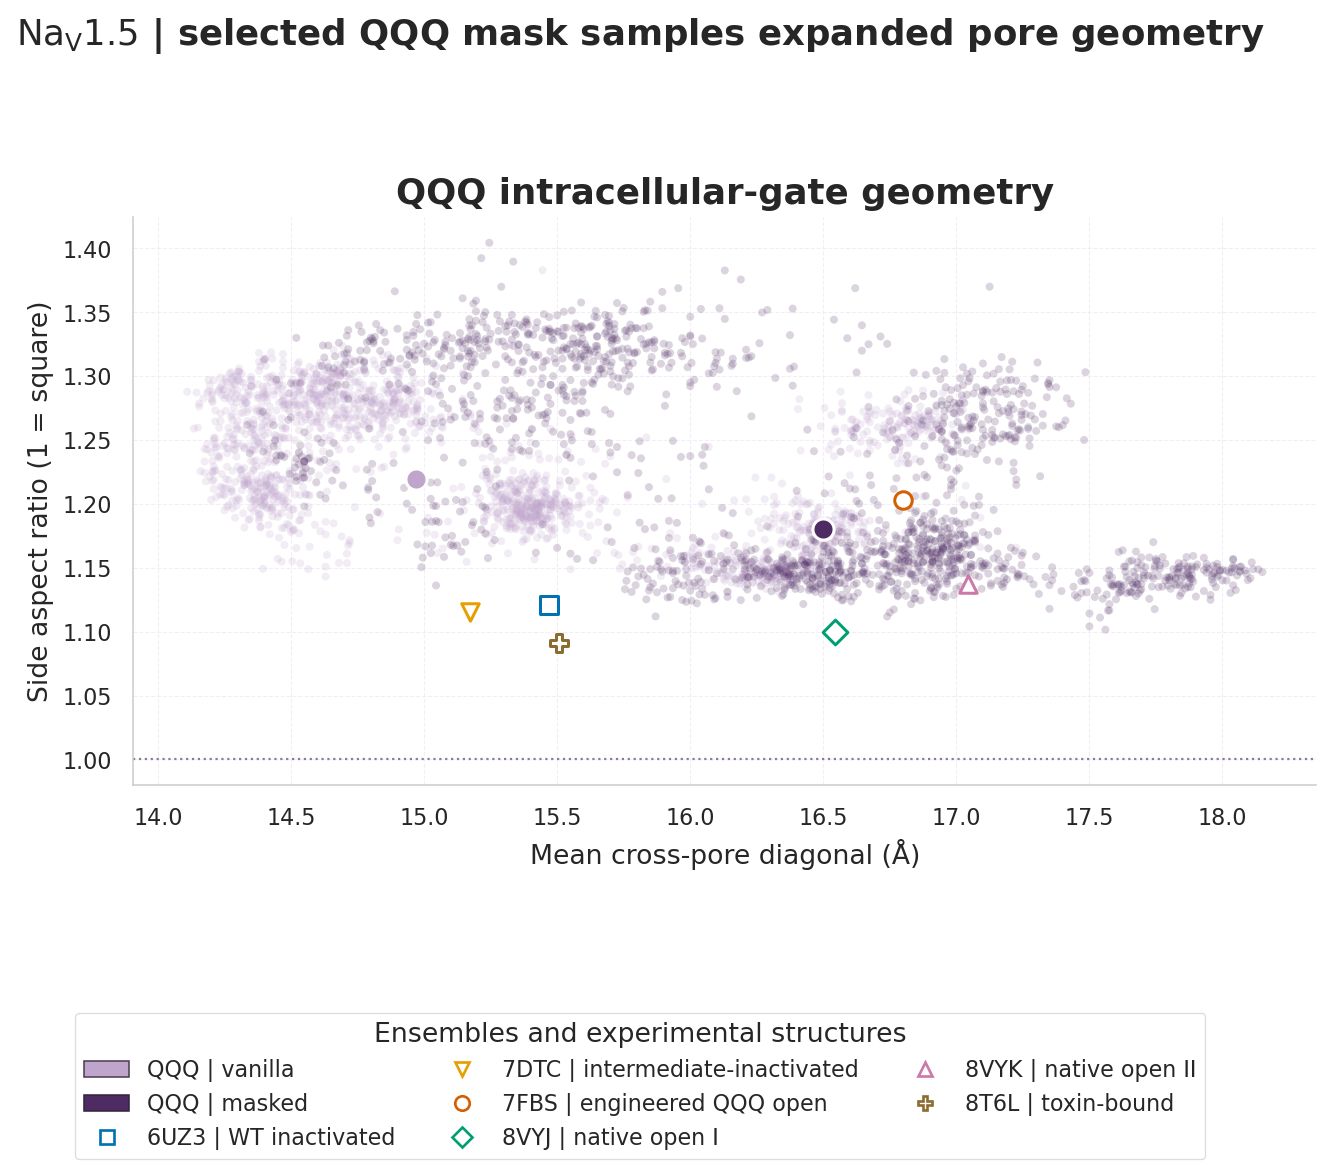

In [4]:
fig, _ = plot_focused_pore_shape(ensemble_shape, experimental_shape)
fig.savefig(figure_dir / 'Nav15_Figure5_focused_pore_shape.png', dpi=600, bbox_inches='tight')
fig.savefig(figure_dir / 'Nav15_Figure5_focused_pore_shape.pdf', bbox_inches='tight')
plt.show()

## Open-pore experimental resemblance

The RMSD panel uses the precomputed final-allOK3 summary rather than dependent recycle snapshots as independent observations. Points show medians, thick intervals show the interquartile range, and thin intervals show the 5th–95th percentile range. Core alignment retains S6 displacement relative to the channel core.

In [5]:
from scripts.ensemble_rmsf_analysis.io import read_csv_resolving_lfs

rmsd_summary = read_csv_resolving_lfs(
    repo_root / 'nav15' / 'dataRMSD' / 'analysis' / 'qqq' / 'summary_statistics.csv',
    repo_root,
)
rmsd_summary = rmsd_summary[
    rmsd_summary['protocol'].isin(['vanilla', 'masked'])
    & rmsd_summary['reference_id'].isin(['7FBS', '8VYJ', '8VYK'])
].copy()
display(
    rmsd_summary[
        rmsd_summary['measurement'].isin([
            'pore_domain__ca__core_aligned_rmsd_A',
            'DII_s6__ca__core_aligned_rmsd_A',
        ])
    ][['protocol', 'reference_id', 'measurement', 'median', 'q25', 'q75', 'p05', 'p95']]
    .sort_values(['measurement', 'reference_id', 'protocol'])
    .round(3)
)

,protocol,reference_id,measurement,median,q25,q75,p05,p95
25,masked,7FBS,DII_s6__ca__core_aligned_rmsd_A,1.049,0.743,2.129,0.470,2.819
157,vanilla,7FBS,DII_s6__ca__core_aligned_rmsd_A,1.868,1.108,2.930,0.758,3.057
47,masked,8VYJ,DII_s6__ca__core_aligned_rmsd_A,1.592,1.194,2.662,1.057,3.331
179,vanilla,8VYJ,DII_s6__ca__core_aligned_rmsd_A,2.186,1.716,3.301,1.115,3.577
58,masked,8VYK,DII_s6__ca__core_aligned_rmsd_A,1.641,1.217,2.670,1.084,3.329
190,vanilla,8VYK,DII_s6__ca__core_aligned_rmsd_A,2.186,1.791,3.296,1.190,3.589
22,masked,7FBS,pore_domain__ca__core_aligned_rmsd_A,1.452,1.378,1.544,1.274,1.791
154,vanilla,7FBS,pore_domain__ca__core_aligned_rmsd_A,1.584,1.460,1.683,1.399,1.788
44,masked,8VYJ,pore_domain__ca__core_aligned_rmsd_A,2.157,2.037,2.245,1.911,2.318
176,vanilla,8VYJ,pore_domain__ca__core_aligned_rmsd_A,2.168,2.094,2.227,1.982,2.294


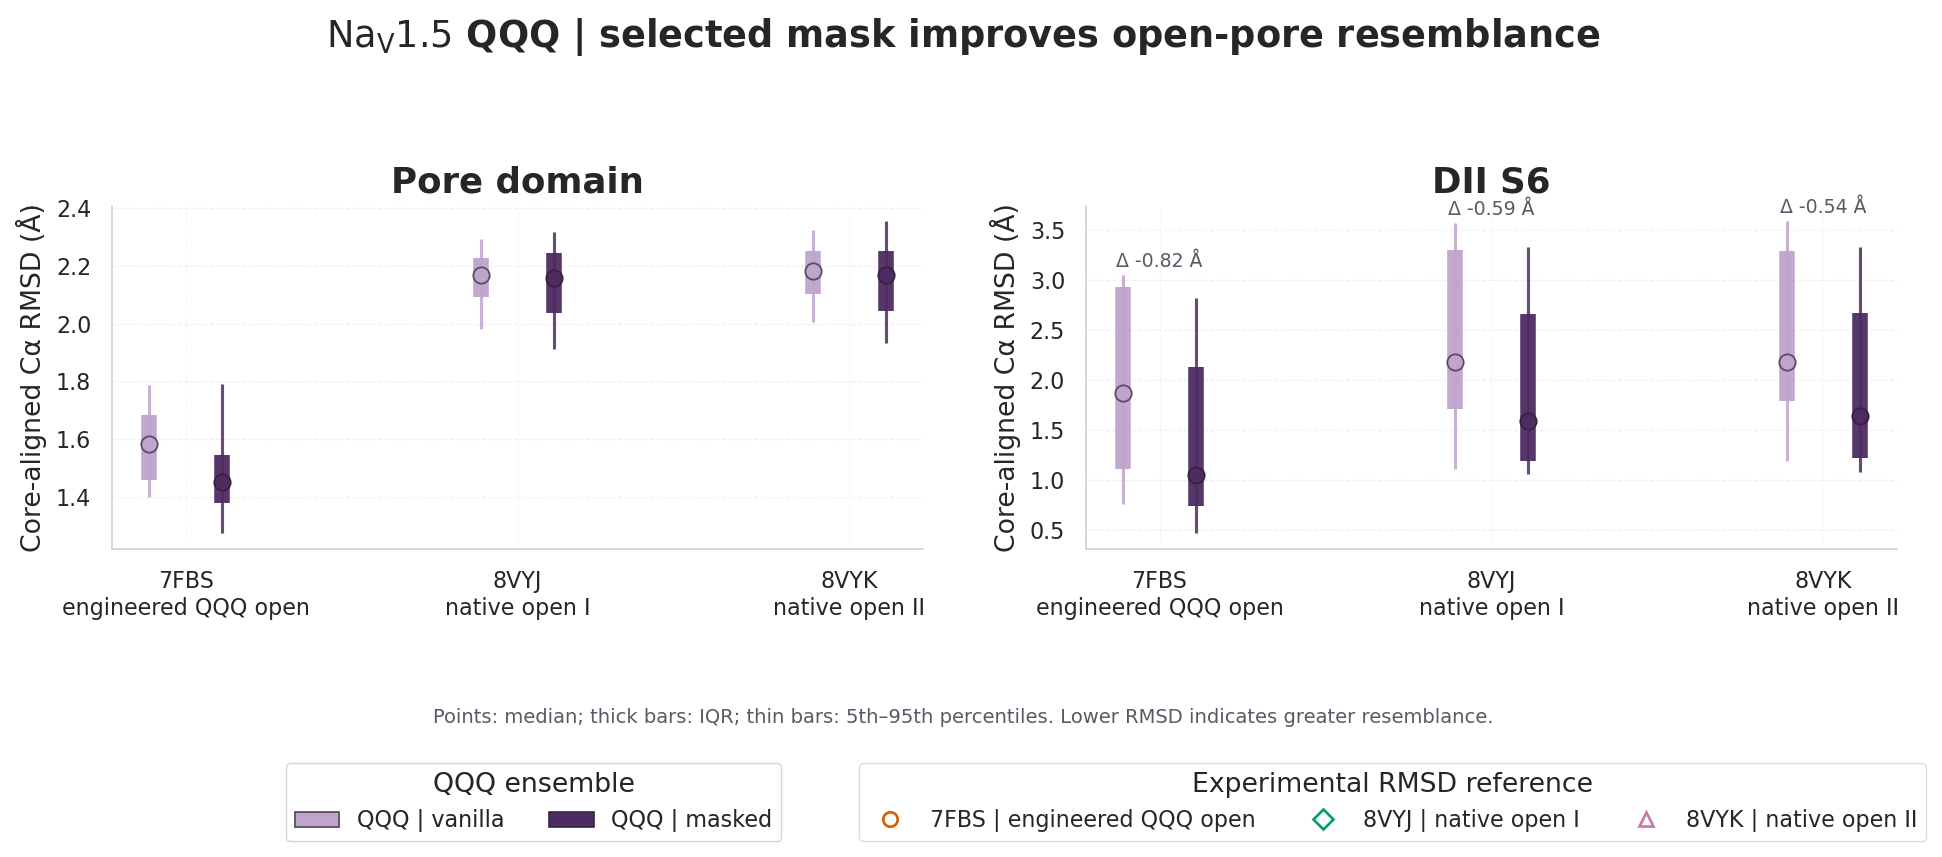

In [6]:
fig = plot_pore_rmsd_summary(rmsd_summary)
fig.savefig(figure_dir / 'Nav15_Figure5_pore_RMSD.png', dpi=600, bbox_inches='tight')
fig.savefig(figure_dir / 'Nav15_Figure5_pore_RMSD.pdf', bbox_inches='tight')
plt.show()

## Recommended Figure 5 panels E and F

The combined export places the focused gate-size/shape landscape beside DII-S6 resemblance to the open references. This pairing is more informative than two marginal pore-shape violins: panel E shows the joint conformational space, whereas panel F provides an experimentally anchored structural comparison.

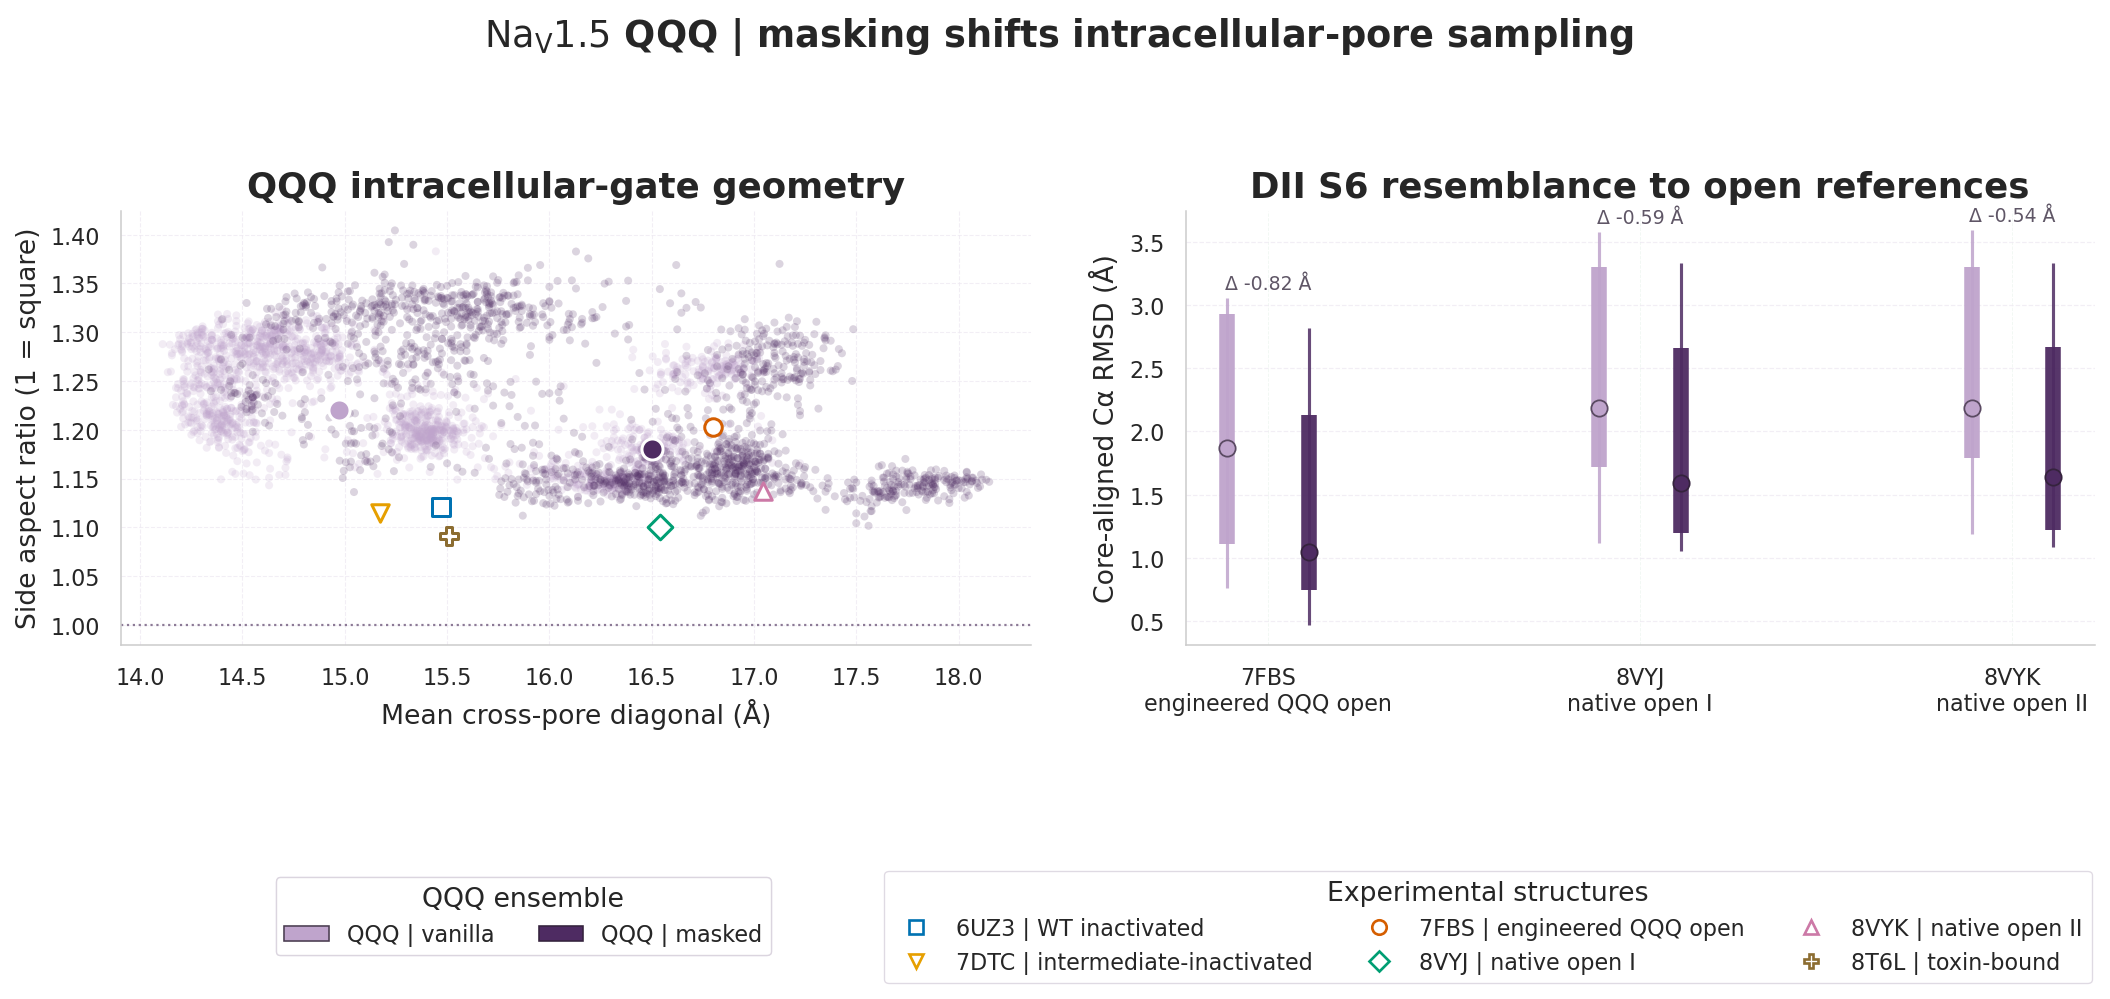

In [7]:
fig = plot_figure5_pore_candidates(ensemble_shape, experimental_shape, rmsd_summary)
fig.savefig(figure_dir / 'Nav15_Figure5_EF_pore_panels.png', dpi=600, bbox_inches='tight')
fig.savefig(figure_dir / 'Nav15_Figure5_EF_pore_panels.pdf', bbox_inches='tight')
plt.show()

## Orthogonal activation-gate geometry

The two opposing-domain gate dimensions are retained separately here rather than collapsed into a mean span. The dashed $y=x$ line marks equal DI–DIII and DII–DIV dimensions; departure from this line reports anisotropy, not simply a larger or smaller pore. Each panel also reports the Spearman association between mean terminal IFM/QQQ engagement distance and mean gate span. This correlation is descriptive and is shown to test coordination rather than assume it.

,Dataset,n,DI–DIII median (Å),DII–DIV median (Å),Mean gate median (Å),Diagonal mismatch median (Å),Engagement-distance median (Å),Spearman engagement–gate
0,WT | vanilla,5000,14.31,15.545,15.075,1.63,11.3,-0.045
1,WT | masked v2,4999,14.53,16.020,15.385,1.72,30.3,0.193
2,QQQ | vanilla,5000,14.21,16.030,14.970,2.11,29.8,-0.008
3,QQQ | masked,4999,15.14,18.010,16.500,3.19,28.9,-0.100


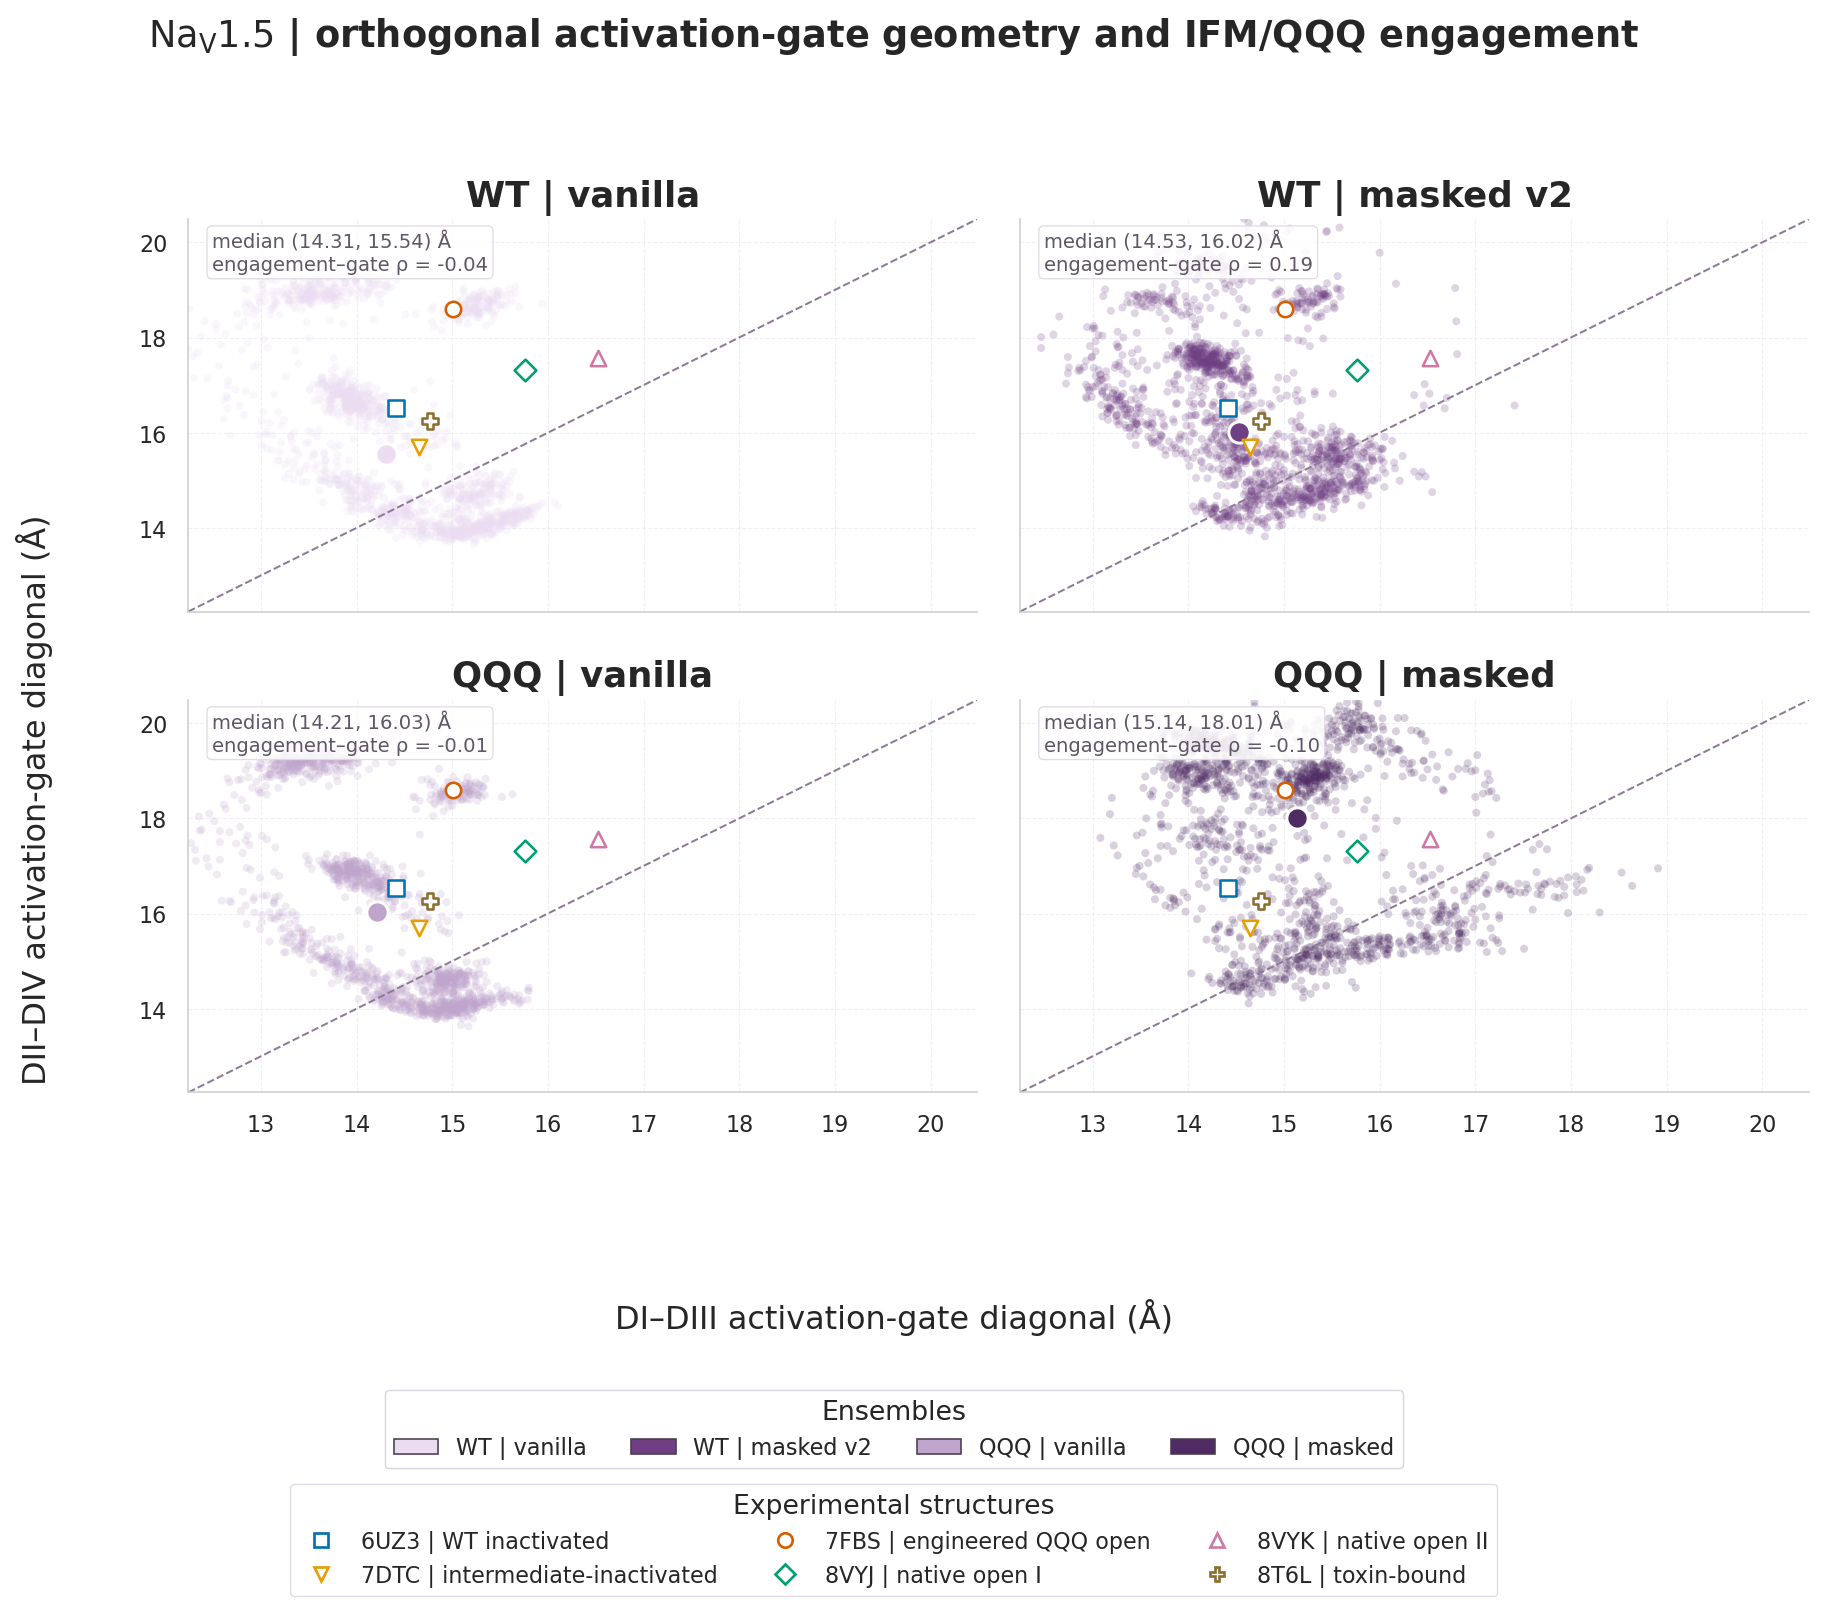

In [8]:
importlib.reload(nav15_figure5)
plot_orthogonal_gate_geometry = nav15_figure5.plot_orthogonal_gate_geometry

orthogonal_gate_summary, orthogonal_gate_figure = plot_orthogonal_gate_geometry(
    datasets,
    experimental_shape,
)
display(orthogonal_gate_summary.round(3))

orthogonal_gate_summary.to_csv(
    repo_root / 'nav15/dataDistances/analysis/tables/Nav15_orthogonal_gate_summary.csv',
    index=False,
)
orthogonal_gate_figure.savefig(
    figure_dir / 'Nav15_Figure5_orthogonal_gate_geometry.png',
    dpi=600,
    bbox_inches='tight',
)
orthogonal_gate_figure.savefig(
    figure_dir / 'Nav15_Figure5_orthogonal_gate_geometry.pdf',
    bbox_inches='tight',
)
plt.show()


## QQQ activation-gate diagonals

This focused version retains only the QQQ vanilla and selected QQQ masked ensembles. The horizontal coordinate is the DI–DIII Cα distance from M415 to I1154; the vertical coordinate is the orthogonal DII–DIV Cα distance from A742 to I1455. These are two explicit cross-pore measurements at the intracellular activation gate, rather than a fitted pore radius. The dashed equality line identifies models with similar opposing-domain spans.

,Dataset,n,DI–DIII median (Å),DII–DIV median (Å),Diagonal mismatch median (Å)
0,QQQ | vanilla,5000,14.21,16.03,2.11
1,QQQ | masked,4999,15.14,18.01,3.19


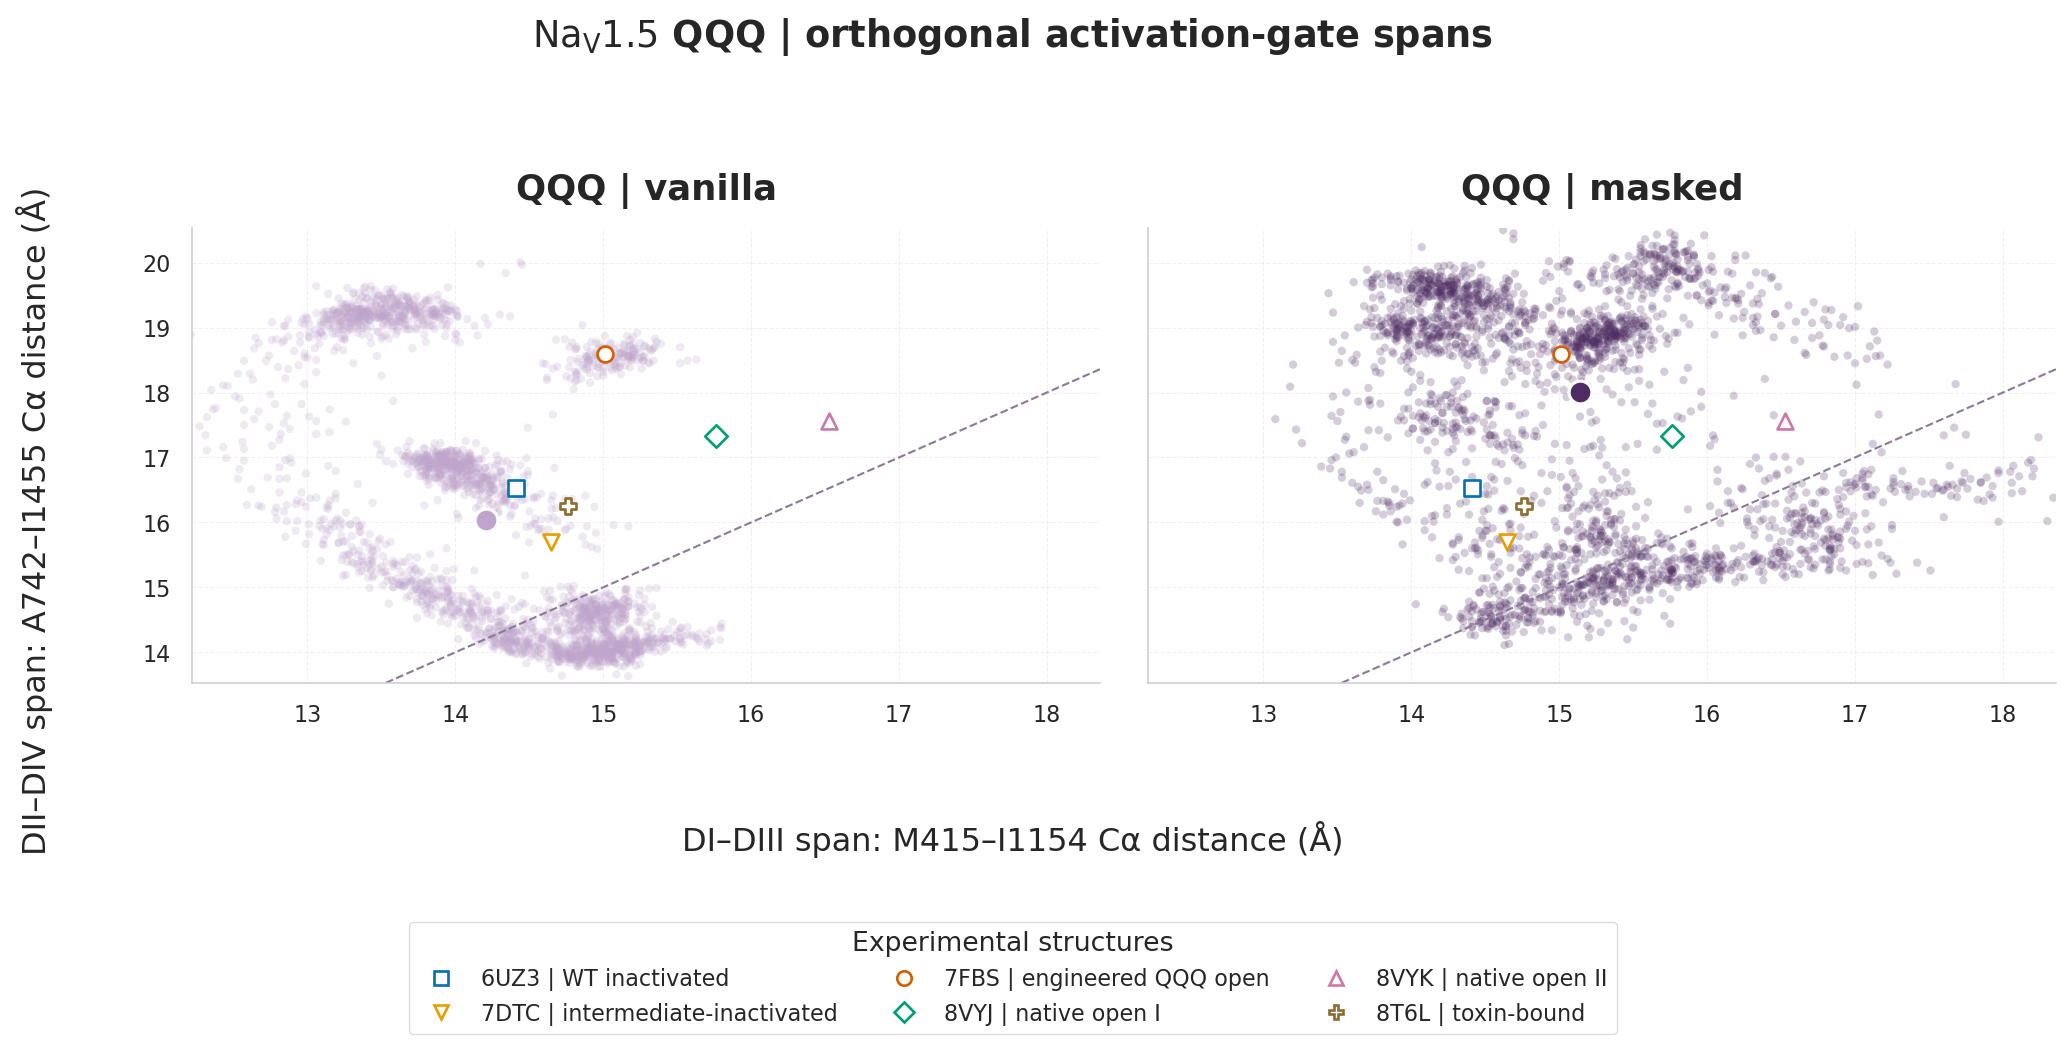

In [9]:
importlib.reload(nav15_figure5)
plot_qqq_activation_gate_diagonals = nav15_figure5.plot_qqq_activation_gate_diagonals

qqq_gate_summary, qqq_gate_figure = plot_qqq_activation_gate_diagonals(
    datasets,
    experimental_shape,
)
display(qqq_gate_summary.round(3))

qqq_gate_summary.to_csv(
    repo_root / 'nav15/dataDistances/analysis/tables/Nav15_QQQ_activation_gate_diagonals.csv',
    index=False,
)
qqq_gate_figure.savefig(
    figure_dir / 'Nav15_Figure5_QQQ_activation_gate_diagonals.png',
    dpi=600,
    bbox_inches='tight',
)
qqq_gate_figure.savefig(
    figure_dir / 'Nav15_Figure5_QQQ_activation_gate_diagonals.pdf',
    bbox_inches='tight',
)
plt.show()


## Interpretation

The intact MSA remains superior for native IFM engagement. The selected QQQ mask instead reweights the mutant ensemble toward a larger intracellular-gate geometry and substantially lower DII-S6 RMSD to experimentally open pore references. The appropriate conclusion is therefore **open-like pore-state exploration**, not restoration of native IFM engagement and not proof of a conducting pore.

## IFM/QQQ separation and intracellular-gate opening

This final panel tests whether motif separation and gate expansion occur together within individual models. Gate openness is the maximum of the six Cα distances connecting the four intracellular-gate landmarks. IFM/QQQ separation is the mean of the two Cα distances from the central motif residue to the sequence-verified receptor asparagines. Each point therefore represents one paired model observation, and Spearman $\rho$ describes monotonic coordination without assuming a linear mechanism.

Larger values on the horizontal axis indicate a wider intracellular gate; larger values on the vertical axis indicate greater separation of the IFM/QQQ motif from its receptor. These Cα-level coordinates complement, but do not replace, the terminal-atom engagement analysis above.

,Dataset,n,Gate median (Å),Gate IQR (Å),IFM/QQQ separation median (Å),IFM/QQQ separation IQR (Å),Spearman gate–engagement
0,WT | vanilla,5000,15.76,3.22,11.923,17.750,-0.035
1,WT | masked v2,4999,16.07,2.15,29.375,1.360,0.356
2,QQQ | vanilla,5000,16.03,3.51,28.990,1.165,0.134
3,QQQ | masked,4999,18.13,3.01,28.680,1.140,0.210


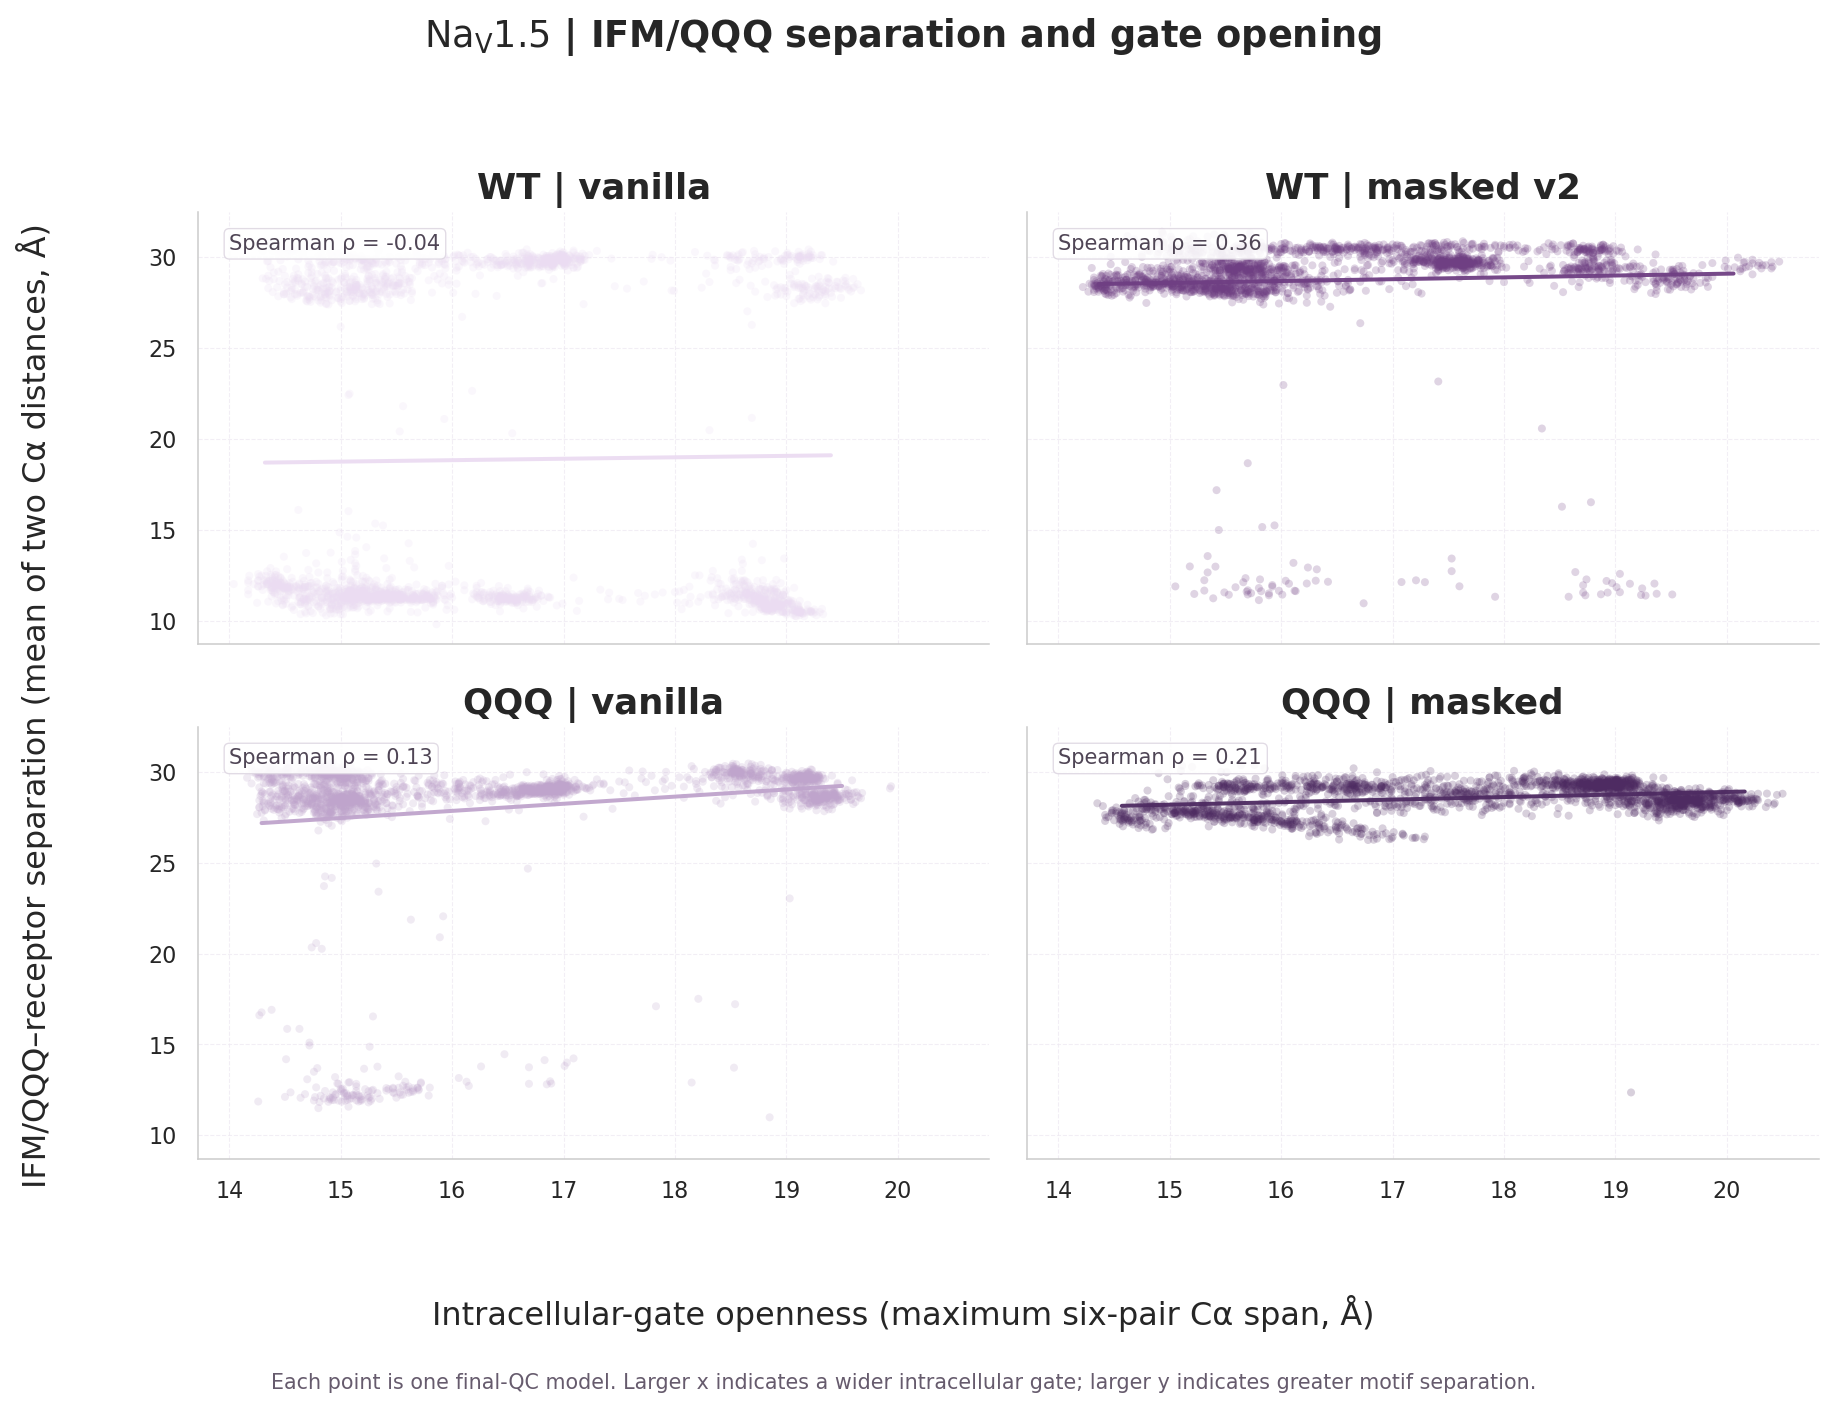

In [10]:
importlib.reload(nav15_figure5)
plot_gate_engagement_coupling = nav15_figure5.plot_gate_engagement_coupling

gate_engagement_summary, gate_engagement_figure = plot_gate_engagement_coupling(
    datasets,
)
display(gate_engagement_summary.round(3))

gate_engagement_summary.to_csv(
    repo_root / 'nav15/dataDistances/analysis/tables/Nav15_gate_engagement_coupling.csv',
    index=False,
)
gate_engagement_figure.savefig(
    figure_dir / 'Nav15_Figure5_gate_engagement_coupling.png',
    dpi=600,
    bbox_inches='tight',
)
gate_engagement_figure.savefig(
    figure_dir / 'Nav15_Figure5_gate_engagement_coupling.pdf',
    bbox_inches='tight',
)
plt.show()
